<a href="https://colab.research.google.com/github/arpitukey26/Projects/blob/main/fakenews(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy matplotlib scikit-learn tensorflow

import torch  # If using PyTorch
print("GPU Available:", torch.cuda.is_available())

import tensorflow as tf  # If using TensorFlow
print("GPU Device:", tf.config.list_physical_devices('GPU'))

# Ensure TensorFlow uses GPU
tf.config.list_physical_devices('GPU')

# Run a simple operation on the GPU
with tf.device('/GPU:0'):
    a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
    b = tf.constant([[5.0, 6.0], [7.0, 8.0]])
    c = tf.matmul(a, b)
print(c)


GPU Available: False
GPU Device: []
tf.Tensor(
[[19. 22.]
 [43. 50.]], shape=(2, 2), dtype=float32)


In [ ]:
!nvidia-smi

!pip install tensorflow-gpu
import nltk

!mkdir -p /root/nltk_data/tokenizers  # Force-create directories
nltk.download('punkt', download_dir='/root/nltk_data')
nltk.download('punkt_tab', download_dir='/root/nltk_data')

/bin/bash: line 1: nvidia-smi: command not found
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import pandas as pd
WELFake = pd.read_csv("/content/drive/MyDrive/AIML DATASET/WELFake_Dataset.csv")
# Check columns (assuming columns: 'text', 'label')
print(WELFake.columns)


Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')


In [ ]:
# Define column names
liar_columns = [
    'id', 'statement', 'subject', 'speaker', 'job_title', 'state_info',
    'party_affiliation', 'barely_true_counts', 'false_counts',
    'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'label'
]

# Load LIAR datasets
liar_train = pd.read_csv(
    "/content/drive/MyDrive/AIML DATASET/train - train (1).csv",
    sep="\t", header=None, names=liar_columns
)
liar_valid = pd.read_csv(
    "/content/drive/MyDrive/AIML DATASET/valid.csv",
    sep="\t", header=None, names=liar_columns
)
liar_test = pd.read_csv(
    "/content/drive/MyDrive/AIML DATASET/test - test (1).csv",
    sep="\t", header=None, names=liar_columns
)

# Combine LIAR splits
liar_combined = pd.concat([liar_train, liar_valid, liar_test], axis=0, ignore_index=True)

# Display basic info
print(liar_combined.info())
print(liar_combined.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13071 entries, 0 to 13070
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    13071 non-null  object 
 1   statement             0 non-null      float64
 2   subject               0 non-null      float64
 3   speaker               0 non-null      float64
 4   job_title             0 non-null      float64
 5   state_info            0 non-null      float64
 6   party_affiliation     0 non-null      float64
 7   barely_true_counts    0 non-null      float64
 8   false_counts          0 non-null      float64
 9   half_true_counts      0 non-null      float64
 10  mostly_true_counts    0 non-null      float64
 11  pants_on_fire_counts  0 non-null      float64
 12  label                 0 non-null      float64
dtypes: float64(12), object(1)
memory usage: 1.3+ MB
None
                                                  id  statement  sub

In [ ]:
isot_fake = pd.read_csv("/content/drive/MyDrive/AIML DATASET/Fake.csv")
isot_true = pd.read_csv("/content/drive/MyDrive/AIML DATASET/True.csv")

# Assign labels: 0 = real, 1 = fake
isot_fake['label'] = 1
isot_true['label'] = 0

# Combine ISOT datasets
isot_combined = pd.concat([isot_fake, isot_true], axis=0)
politifact_real = pd.read_csv("/content/drive/MyDrive/AIML DATASET/politifact_real.csv")
politifact_fake = pd.read_csv("/content/drive/MyDrive/AIML DATASET/politifact_fake.csv")
gossipcop_real = pd.read_csv("/content/drive/MyDrive/AIML DATASET/gossipcop_real.csv")
gossipcop_fake = pd.read_csv("/content/drive/MyDrive/AIML DATASET/gossipcop_fake (1).csv")


In [ ]:
# Add labels to Politifact and GossipCop datasets
politifact_real['label'] = 0
politifact_fake['label'] = 1
gossipcop_real['label'] = 0
gossipcop_fake['label'] = 1

# Combine Politifact and GossipCop
politifact_combined = pd.concat([politifact_real, politifact_fake], axis=0)
gossipcop_combined = pd.concat([gossipcop_real, gossipcop_fake], axis=0)
WELFake = WELFake[['text', 'label']]
print(liar_combined.columns.tolist())  # Check exact column names

# Use 'statement' instead of 'text' for liar_combined
liar_combined = liar_combined[['statement', 'label']]  # Changed 'text' to 'statement'
liar_combined = liar_combined.rename(columns={'statement': 'text'}) # Renaming the column to 'text'

isot_combined = isot_combined[['text', 'label']]
# Example: If Politifact uses 'content' instead of 'text'
politifact_combined = politifact_combined.rename(columns={'content': 'text'})
gossipcop_combined = gossipcop_combined.rename(columns={'content': 'text'})

['id', 'statement', 'subject', 'speaker', 'job_title', 'state_info', 'party_affiliation', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'label']


In [ ]:
# Combine all datasets vertically
final_df = pd.concat([
    WELFake,
    liar_combined,
    isot_combined,
    politifact_combined,
    gossipcop_combined
], axis=0)

In [ ]:
# Shuffle the data
final_df = final_df.sample(frac=1).reset_index(drop=True)
final_df = final_df.dropna(subset=['text', 'label'])
final_df = final_df.drop_duplicates(subset=['text'])
print(final_df['label'].value_counts())
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

label
0.0    34620
1.0    28098
Name: count, dtype: int64


In [ ]:
# Download required NLP resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
final_df['text'] = final_df['text'].fillna('')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = nltk.word_tokenize(text)
    filtered_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(filtered_tokens)

In [ ]:
# Apply preprocessing
final_df['cleaned_text'] = final_df['text'].apply(preprocess_text)
final_df.to_csv('combined_fake_news_dataset.csv', index=False)
# Install required libraries
!pip install pandas numpy matplotlib seaborn nltk scikit-learn tensorflow lime textblob
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=8a2c9c8c2494225f346dc0c8d1bbe395a693087884074048f93ba73e4db43123
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [ ]:
# Load dataset
df = pd.read_csv('combined_fake_news_dataset.csv')

In [ ]:
# Check class balance
print("Class Distribution:\n", df['label'].value_counts())

# Text Preprocessing
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

Class Distribution:
 label
0.0    34620
1.0    28098
Name: count, dtype: int64


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = nltk.word_tokenize(text)
    filtered_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(filtered_tokens)

In [ ]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.decomposition import TruncatedSVD

In [ ]:
# Apply preprocessing
df['cleaned_text'] = df['text'].apply(preprocess_text)

# TF-IDF Vectorization (5000 most frequent words)
vectorizer = TfidfVectorizer(max_features=3000)  # Reduced from 5000
X_tfidf = vectorizer.fit_transform(df['cleaned_text'])

# Dimensionality reduction
svd = TruncatedSVD(n_components=1000)  # Keep top 1000 components
X = svd.fit_transform(X_tfidf)
y = df['label']

In [ ]:
# Split into train/test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
def build_model():
    model = Sequential()

    # Input layer with L2 regularization + BatchNorm
    model.add(Dense(64, input_dim=X_train.shape[1], activation='relu', kernel_regularizer=l2(0.01)))
    model.add(BatchNormalization())
    model.add(Dropout(0.7))  # Increased dropout

    # Hidden layer
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.01)))  # Reduced neurons
    model.add(BatchNormalization())
    model.add(Dropout(0.7))

    model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.01)))  # Reduced neurons
    model.add(BatchNormalization())
    model.add(Dropout(0.7))

    # Output
    model.add(Dense(1, activation='sigmoid'))

    # Optimizer with lower learning rate + gradient clipping
    optimizer = Adam(learning_rate=0.0001, clipvalue=1.0)  # Reduced LR from 0.001
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    return model
    # Initialize model with ReLU activation
model = build_model()
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │          64,064 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 66,561 (260.00 KB)

 Trainable params: 66,369 (259.25 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
# Calculate class weights for imbalanced data
class_counts = np.bincount(y_train)
total_samples = len(y_train)
class_weights = {
    0: total_samples / (2 * class_counts[0]),  # Weight for class 0
    1: total_samples / (2 * class_counts[1])   # Weight for class 1
}

In [ ]:
# Add learning rate scheduler callback
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,  # Reduce LR by 80% on plateau
    patience=2,   # Wait 2 epochs
    min_lr=1e-7   # Minimum learning rate
)

# Update Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,  # Increased from 3
    restore_best_weights=True
)

# Train with class weights
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, lr_scheduler],  # Added lr_scheduler
    class_weight=class_weights,            # Added class weights
    verbose=1
)

Epoch 1/20
628/628 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.5174 - loss: 2.6595 - val_accuracy: 0.6142 - val_loss: 2.0436 - learning_rate: 1.0000e-04
Epoch 2/20
628/628 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5809 - loss: 2.2132 - val_accuracy: 0.8019 - val_loss: 1.6750 - learning_rate: 1.0000e-04
Epoch 3/20
628/628 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6615 - loss: 1.8297 - val_accuracy: 0.8636 - val_loss: 1.3787 - learning_rate: 1.0000e-04
Epoch 4/20
628/628 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7417 - loss: 1.4948 - val_accuracy: 0.8983 - val_loss: 1.1206 - learning_rate: 1.0000e-04
Epoch 5/20
628/628 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8115 - loss: 1.2074 - val_accuracy: 0.9137 - val_loss: 0.9039 - learning_rate: 1.0000e-04
Epoch 6/20
628/628 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8485 - loss: 0.9812 - val_accuracy: 0.9226 - val_loss: 0.7279 - learning_rate: 1.0000e-04
Epoch 7/20
628/628 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 

392/392 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Accuracy: 0.9450733418367347
Precision: 0.925306192858375
Recall: 0.9544483985765124
F1-Score: 0.9396513970395025
AUC-ROC: 0.9866420578481983


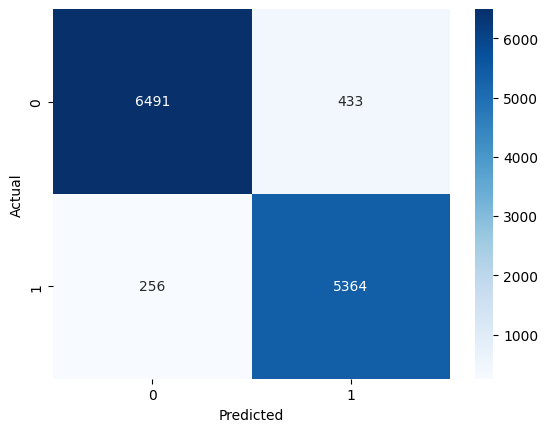

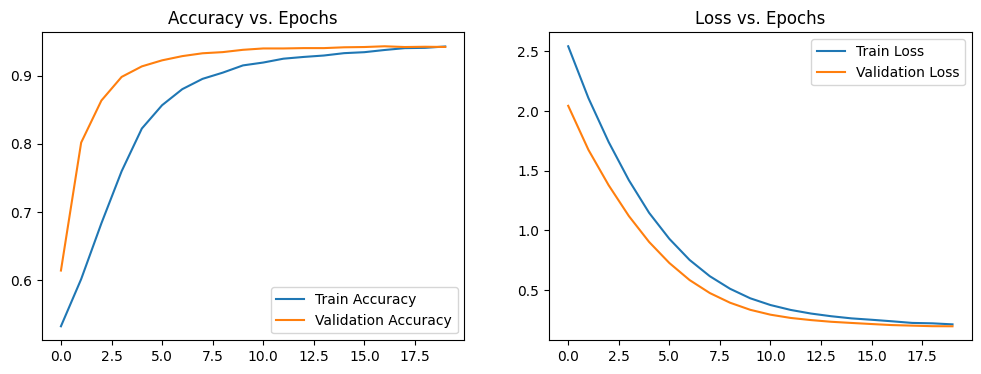

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict probabilities
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)
# Calculate metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_pred_prob))
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
# Learning Curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs. Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs. Epochs')
plt.legend()
plt.show()

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split # Import train_test_split here
from sklearn.feature_extraction.text import TfidfVectorizer # Import TfidfVectorizer here



# Load dataset
df = pd.read_csv('combined_fake_news_dataset.csv')  # Replace with your actual file path

# Check the first 5 rows to confirm it loaded
print(df.head())
print("Missing values in 'cleaned_text':", df['cleaned_text'].isna().sum())
# Drop rows with missing 'cleaned_text'
df = df.dropna(subset=['cleaned_text'])
# Check again
print("Missing values after cleanup:", df['cleaned_text'].isna().sum())
# Replace empty strings with a placeholder (e.g., "no_text")
df['cleaned_text'] = df['cleaned_text'].replace('', 'no_text_after_cleaning')

                                                text  label  id  news_url  \
0  NEW YORK (Reuters) - Japanese Prime Minister S...    0.0 NaN       NaN   
1  SANT CUGAT DEL VALLÈS, Spain  —   Monday marks...    0.0 NaN       NaN   
2  MEXICO CITY (Reuters) - Mexican President Enri...    0.0 NaN       NaN   
3  On October 20, 2015, radical Muslim State sena...    1.0 NaN       NaN   
4  MEXICO CITY (Reuters) - The first man in moder...    0.0 NaN       NaN   

   title  tweet_ids                                       cleaned_text  
0    NaN        NaN  new york reuters japanese prime minister shinz...  
1    NaN        NaN  sant cugat del valls spain monday mark year si...  
2    NaN        NaN  mexico city reuters mexican president enrique ...  
3    NaN        NaN  october radical muslim state senator jamilah r...  
4    NaN        NaN  mexico city reuters first man modern mexican h...  
Missing values in 'cleaned_text': 105
Missing values after cleanup: 0


In [ ]:
# TF-IDF Vectorization with 5000 features
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(df['cleaned_text']).toarray()  # Added .toarray()

# Dimensionality reduction to 1000 features for BOTH train and test data
svd = TruncatedSVD(n_components=1000)
X_svd = svd.fit_transform(X_tfidf)  # Apply SVD to the entire dataset

# Get the target variable from the dataframe
y = df['label']  # Make sure 'y' is consistent with the current df

# Now split data using transformed data
X_train, X_test, y_train, y_test = train_test_split(X_svd, y, test_size=0.2, stratify=y, random_state=42)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


392/392 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
                 Model  Accuracy  F1-Score  Training Time (s)
0  Logistic Regression  0.755570  0.721144           6.276230
1          Naive Bayes  0.638186  0.440133           0.215457
2                  MLP  0.807075  0.771731          84.716989


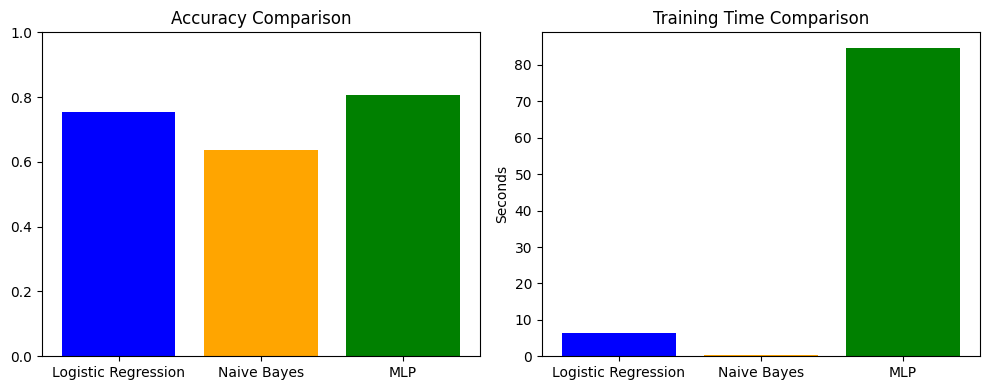

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score
import time

# Initialize models
lr_model = LogisticRegression(max_iter=1000)  # Increase max_iter for convergence
nb_model = MultinomialNB()

# Train and evaluate Logistic Regression
start_time = time.time()
lr_model.fit(X_train, y_train)
lr_train_time = time.time() - start_time
y_pred_lr = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

# Train and evaluate Naive Bayes
start_time = time.time()
nb_model.fit(X_train, y_train)
nb_train_time = time.time() - start_time
y_pred_nb = nb_model.predict(X_test)
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

def build_mlp():
    model = Sequential()
    model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

mlp_model = build_mlp()
early_stop = EarlyStopping(monitor='val_loss', patience=3)

# Train MLP and measure time
start_time = time.time()
history = mlp_model.fit(X_train, y_train, epochs=20, batch_size=64, validation_split=0.2, callbacks=[early_stop], verbose=0)
mlp_train_time = time.time() - start_time

# Evaluate MLP
y_pred_mlp = (mlp_model.predict(X_test) > 0.5).astype(int)
mlp_accuracy = accuracy_score(y_test, y_pred_mlp)
mlp_f1 = f1_score(y_test, y_pred_mlp)
import matplotlib.pyplot as plt

# Create a DataFrame for comparison
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'MLP'],
    'Accuracy': [lr_accuracy, nb_accuracy, mlp_accuracy],
    'F1-Score': [lr_f1, nb_f1, mlp_f1],
    'Training Time (s)': [lr_train_time, nb_train_time, mlp_train_time]
})

print(results)

# Plot F1-Scores and Training Time
plt.figure(figsize=(10, 4))

# F1-Score Comparison
plt.subplot(1, 2, 1)
plt.bar(results['Model'], results['Accuracy'], color=['blue', 'orange', 'green'])
plt.title('Accuracy Comparison')
plt.ylim(0, 1)

# Training Time Comparison
plt.subplot(1, 2, 2)
plt.bar(results['Model'], results['Training Time (s)'], color=['blue', 'orange', 'green'])
plt.title('Training Time Comparison')
plt.ylabel('Seconds')

plt.tight_layout()
plt.show()